# Занятие 10. Технологии ускорения и распараллеливания вычислений в Python

На этом семинаре мы рассмотрим различные подходы к ускорению вычислений в Python
на примере классической задачи — генерации фрактала Мандельброта. Мы пройдем
путь от наивной реализации до высокопроизводительных вычислений на GPU.

In [6]:
%matplotlib inline

In [7]:
%config InlineBackend.figure_format = 'retina'

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange, cuda
import time

## 1. Наивная реализация на чистом Python ##

Это самый простой и медленный подход. Мы используем два вложенных цикла для
итерации по каждому пикселю изображения. Этот код легко написать и понять,
но он крайне неэффективен из-за интерпретируемой природы Python.

In [9]:
def mandelbrot_python(w, h, max_iters=100):
    """
    Рассчитывает фрактал Мандельброта на чистом Python.
    """
    img = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):  # y-координата (строка)
        for j in range(w):  # x-координата (столбец)
            c = complex(-2.0 + 3.0 * j / (w - 1), -1.5 + 3.0 * i / (h - 1))
            z = 0
            n = 0
            while abs(z) <= 2.0 and n < max_iters:
                z = z*z + c
                n += 1
            
            # Раскрашиваем пиксель в зависимости от числа итераций
            color = 255 - int(255 * n / max_iters)
            img[i, j] = color
    return img

## 2. Векторизация с помощью Numpy ##

Numpy позволяет выполнять операции над целыми массивами данных без явных циклов
в Python. Это называется векторизацией. Операции выполняются на уровне
скомпилированного C-кода, что дает значительное ускорение.

In [10]:
def mandelbrot_numpy(w, h, max_iters=100):
    """
    Рассчитывает фрактал Мандельброта с использованием векторизации Numpy.
    """
    y, x = np.ogrid[-1.5:1.5:h*1j, -2.0:1.0:w*1j]
    c = x + y*1j
    z = c
    # Массив для хранения итерации, на которой точка "убежала"
    diverge_time = max_iters + np.zeros(z.shape, dtype=int)

    for i in range(max_iters):
        z = z**2 + c
        # Находим точки, которые вышли за пределы радиуса 2
        diverged = np.abs(z) > 2.0
        # Отмечаем те, что вышли именно на этой итерации
        diverging_now = diverged & (diverge_time == max_iters)
        diverge_time[diverging_now] = i
        # "Успокаиваем" убежавшие точки, чтобы избежать overflow
        z[diverged] = 2.0 
    
    return diverge_time

## 3. Ускорение на CPU с Numba JIT ##

Numba — это Just-In-Time (JIT) компилятор, который переводит код Python в
быстрый машинный код "на лету". Декоратор `@njit` включает компиляцию
в режиме "nopython", что дает максимальную производительность, сравнимую с C.

In [11]:
# Компилируем только самую вычислительно нагруженную часть - внутренний цикл
@njit
def mandel_iter_numba(c, max_iters):
    z = 0
    n = 0
    while abs(z) <= 2.0 and n < max_iters:
        z = z*z + c
        n += 1
    return n

In [12]:
def mandelbrot_numba_cpu(w, h, max_iters=100):
    """
    Рассчитывает фрактал Мандельброта с JIT-компиляцией от Numba.
    """
    img = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            c = complex(-2.0 + 3.0 * j / (w - 1), -1.5 + 3.0 * i / (h - 1))
            n = mandel_iter_numba(c, max_iters)
            color = 255 - int(255 * n / max_iters)
            img[i, j] = color
    return img

## 4. Распараллеливание на CPU с Numba ##

Numba может автоматически распараллеливать циклы на все доступные ядра CPU.
Для этого достаточно добавить `parallel=True` в декоратор и заменить `range`
на `prange`. Это позволяет утилизировать всю мощь современного многоядерного
процессора.

In [13]:
@njit(parallel=True)
def mandelbrot_numba_parallel_cpu(w, h, max_iters=100):
    """
    Рассчитывает фрактал Мандельброта с параллелизацией на CPU от Numba.
    """
    img = np.zeros((h, w), dtype=np.uint8)
    # Используем prange для распараллеливания внешнего цикла
    for i in prange(h):
        for j in range(w):
            c = complex(-2.0 + 3.0 * j / (w - 1), -1.5 + 3.0 * i / (h - 1))
            z = 0
            n = 0
            while abs(z) <= 2.0 and n < max_iters:
                z = z*z + c
                n += 1
            color = 255 - int(255 * n / max_iters)
            img[i, j] = color
    return img

## 5. Вычисления на GPU с Numba.cuda ##

Для массового параллелизма мы можем использовать GPU. Numba.cuda позволяет
писать "ядра" (kernels) — специальные функции, которые выполняются на GPU
в тысячах потоков одновременно. Каждый поток будет обрабатывать свой пиксель.

In [14]:
@cuda.jit
def mandelbrot_cuda_kernel(min_x, max_x, min_y, max_y, image, max_iters):
    """
    CUDA ядро: каждый поток вычисляет цвет одного пикселя.
    """
    # Узнаем глобальные координаты потока в гриде
    i, j = cuda.grid(2)
    
    height, width = image.shape
    
    # Убедимся, что поток не выходит за границы изображения
    if i >= width or j >= height:
        return

    # Преобразуем координаты пикселя в координаты на комплексной плоскости
    pixel_size_x = (max_x - min_x) / width
    pixel_size_y = (max_y - min_y) / height
    c = complex(min_x + i * pixel_size_x, min_y + j * pixel_size_y)
    
    # Итерационный процесс
    z = 0
    n = 0
    while abs(z) <= 2.0 and n < max_iters:
        z = z*z + c
        n += 1
        
    color = 255 - int(255 * n / max_iters)
    image[j, i] = color

In [15]:
def mandelbrot_numba_gpu(w, h, max_iters=100):
    """
    Хост-функция для запуска вычислений на GPU.
    """
    # Создаем массив на CPU
    image = np.zeros((h, w), dtype=np.uint8)
    
    # Копируем массив в память GPU
    d_image = cuda.to_device(image)
    
    # Задаем конфигурацию грида: количество потоков в блоке
    threadsperblock = (16, 16)
    # Рассчитываем количество блоков в гриде
    blockspergrid_x = int(np.ceil(w / threadsperblock[0]))
    blockspergrid_y = int(np.ceil(h / threadsperblock[1]))
    blockspergrid = (blockspergrid_x, blockspergrid_y)
    
    # Запускаем ядро на GPU
    mandelbrot_cuda_kernel[blockspergrid, threadsperblock](-2.0, 1.0, -1.5, 1.5, d_image, max_iters)
    
    # Копируем результат обратно с GPU на CPU
    result_image = d_image.copy_to_host()
    
    return result_image

## Сравнение производительности ##

Теперь запустим все реализации и сравним время их выполнения.
Обратите внимание, что для Numba-функций первый запуск включает время
компиляции, поэтому мы делаем "прогревочный" запуск на малых данных.

In [16]:
# Параметры
WIDTH = 1200
HEIGHT = 900
MAX_ITERS = 150

# Словарь для хранения времени выполнения
timings = {}

# --- 1. Pure Python ---
print("Running Pure Python version...")
start_time = time.time()
mandel_python = mandelbrot_python(WIDTH, HEIGHT, MAX_ITERS)
timings['Pure Python'] = time.time() - start_time
print(f"  Done in {timings['Pure Python']:.4f} seconds")

# --- 2. Numpy ---
print("Running Numpy version...")
start_time = time.time()
mandel_numpy_iters = mandelbrot_numpy(WIDTH, HEIGHT, MAX_ITERS)
# Конвертируем итерации в цвета
mandel_numpy = (255 - (255 * mandel_numpy_iters / MAX_ITERS)).astype(np.uint8)
timings['Numpy'] = time.time() - start_time
print(f"  Done in {timings['Numpy']:.4f} seconds")

# --- 3. Numba CPU ---
print("Running Numba CPU version...")
mandelbrot_numba_cpu(10, 10, 10) # Прогрев для JIT-компиляции
start_time = time.time()
mandel_numba_cpu = mandelbrot_numba_cpu(WIDTH, HEIGHT, MAX_ITERS)
timings['Numba CPU'] = time.time() - start_time
print(f"  Done in {timings['Numba CPU']:.4f} seconds")

# --- 4. Numba Parallel CPU ---
print("Running Numba Parallel CPU version...")
mandelbrot_numba_parallel_cpu(10, 10, 10) # Прогрев
start_time = time.time()
mandel_numba_parallel = mandelbrot_numba_parallel_cpu(WIDTH, HEIGHT, MAX_ITERS)
timings['Numba Parallel CPU'] = time.time() - start_time
print(f"  Done in {timings['Numba Parallel CPU']:.4f} seconds")

# --- 5. Numba GPU ---
print("Running Numba GPU version...")
try:
    mandelbrot_numba_gpu(10, 10, 10) # Прогрев
    start_time = time.time()
    mandel_gpu = mandelbrot_numba_gpu(WIDTH, HEIGHT, MAX_ITERS)
    timings['Numba GPU'] = time.time() - start_time
    print(f"  Done in {timings['Numba GPU']:.4f} seconds")
    gpu_available = True
except Exception as e:
    print(f"Не удалось запустить GPU версию: {e}")
    gpu_available = False

Running Pure Python version...
  Done in 2.5906 seconds
Running Numpy version...
  Done in 1.8838 seconds
Running Numba CPU version...
  Done in 0.4882 seconds
Running Numba Parallel CPU version...
  Done in 0.0250 seconds
Running Numba GPU version...
  Done in 0.0065 seconds


c:\Users\Artem\AppData\Local\Programs\Python\Python312\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


## Визуализация результатов ##

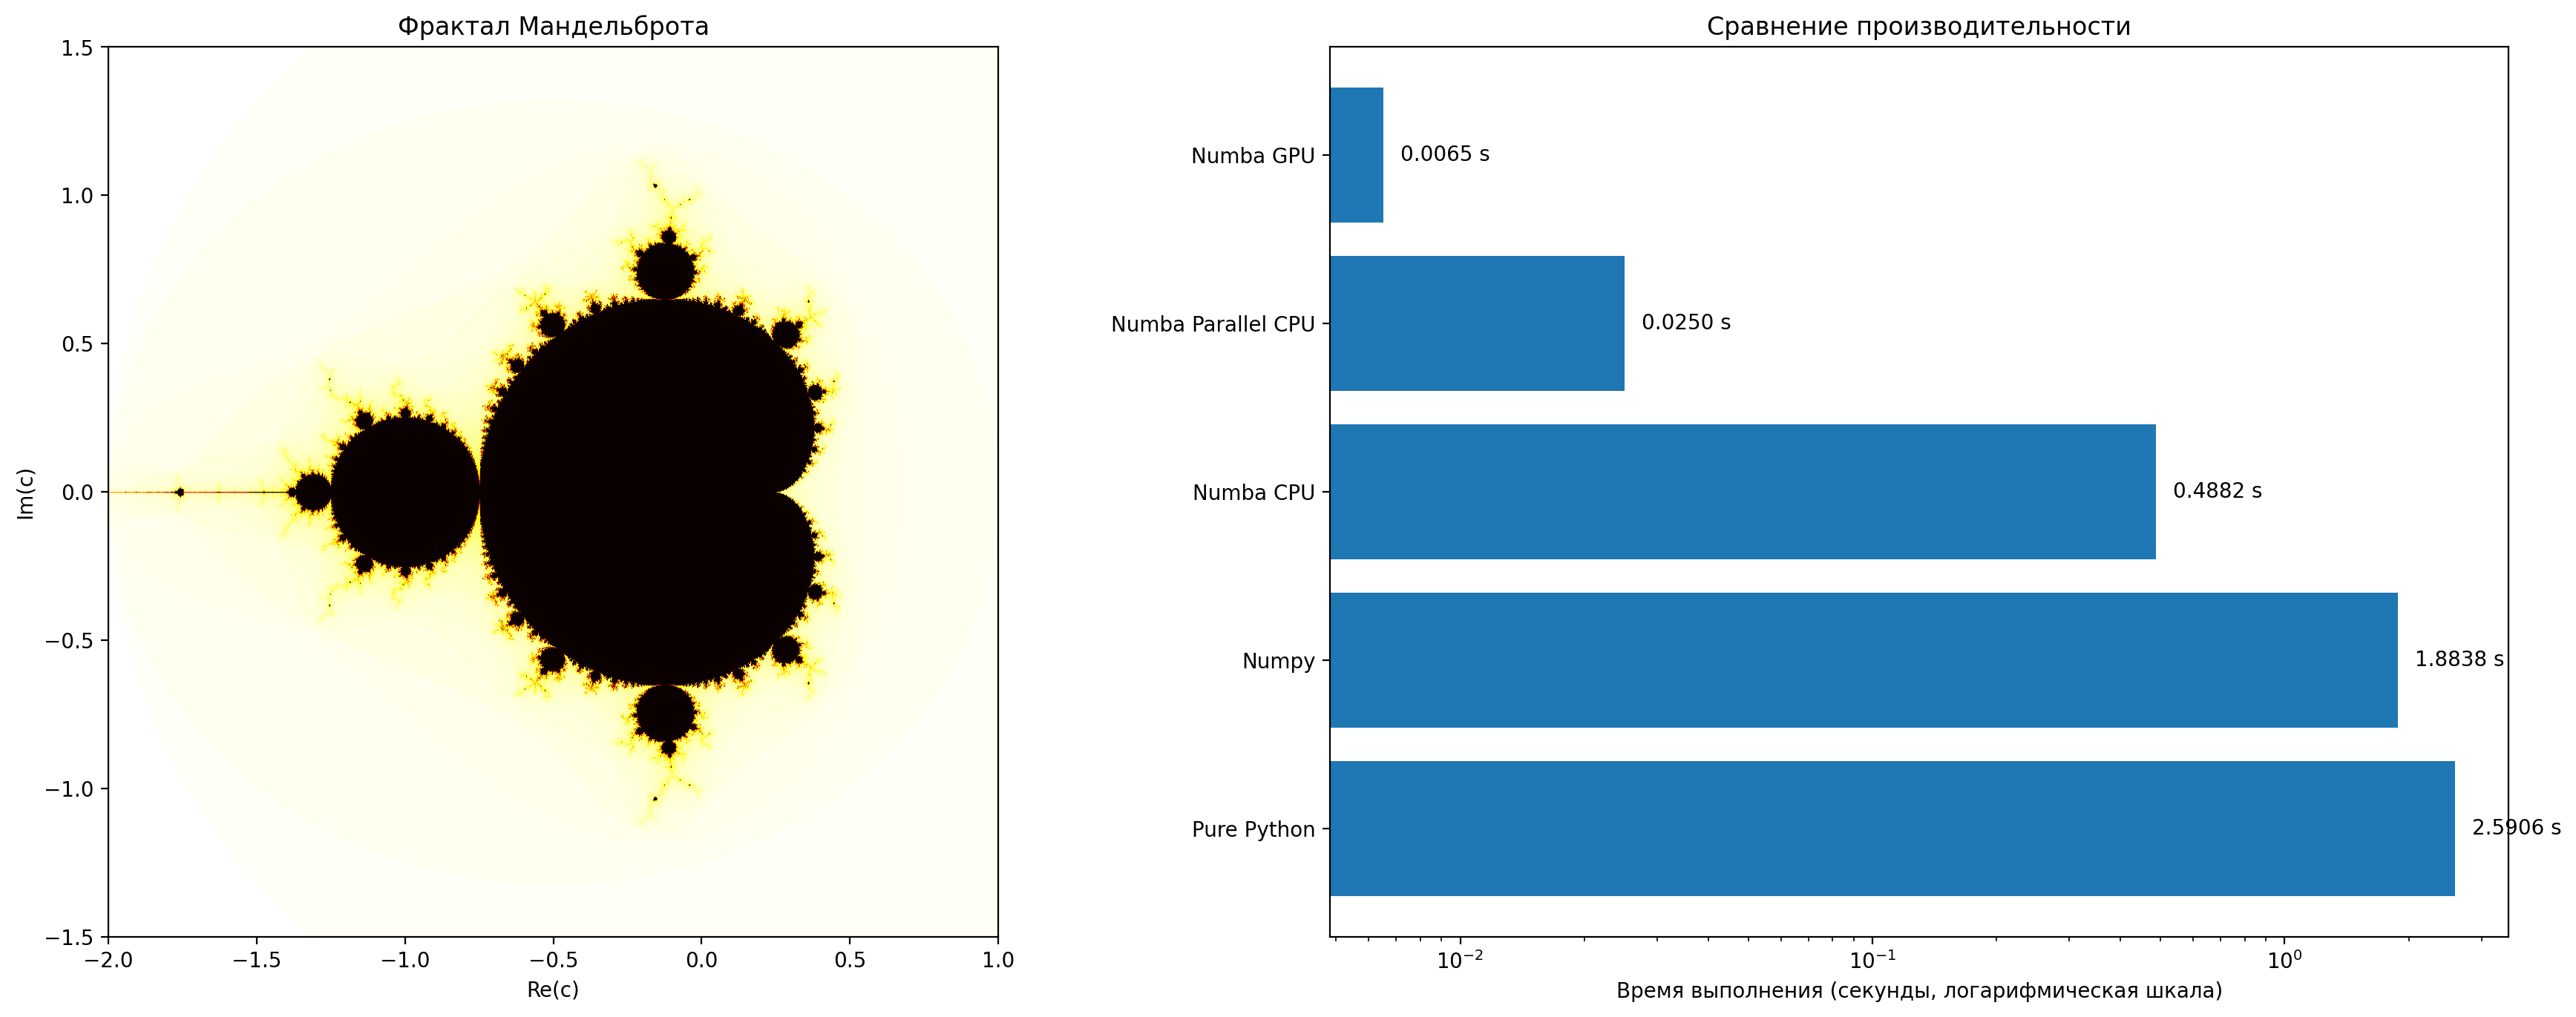

In [17]:
# Создаем фигуру для графиков
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# 1. Изображение фрактала (берем результат с GPU, если он есть)
final_image = mandel_gpu if gpu_available else mandel_numba_parallel
ax[0].imshow(final_image, cmap='hot', extent=[-2, 1, -1.5, 1.5])
ax[0].set_title('Фрактал Мандельброта')
ax[0].set_xlabel('Re(c)')
ax[0].set_ylabel('Im(c)')

# 2. График производительности
names = list(timings.keys())
values = list(timings.values())
bars = ax[1].barh(names, values)
ax[1].set_xlabel('Время выполнения (секунды, логарифмическая шкала)')
ax[1].set_title('Сравнение производительности')
ax[1].set_xscale('log') # Логарифмическая шкала для наглядности

# Добавляем подписи со временем на график
for bar in bars:
    width = bar.get_width()
    ax[1].text(width * 1.1, bar.get_y() + bar.get_height()/2,
                f'{width:.4f} s',
                va='center')

plt.tight_layout()
plt.show()

## Выводы ##

Как видно из графика, каждый следующий шаг оптимизации дает кратное
ускорение.
- **Numpy** значительно быстрее чистого Python.
- **Numba JIT** обгоняет Numpy, так как устраняет накладные расходы на создание
  промежуточных массивов.
- **Параллелизация на CPU** дает дополнительный прирост, пропорциональный
  количеству ядер.
- **GPU** демонстрирует самое большое ускорение благодаря массовому параллелизму,
  обрабатывая тысячи пикселей одновременно.

Этот пример показывает, как современные инструменты Python позволяют эффективно
использовать всю мощь оборудования для научных и инженерных вычислений.